# Loan Default Risk with Business Cost Optimization

Objective:Predict the likelihood of a loan default and optimize the decision threshold based on cost-
benefit analysis.

In [3]:
pip install imbalanced-learn catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 889.5 kB/s eta 0:01:53
   ---------------------------------------- 0.5/100.2 MB 889.5 kB/s eta 0:01:53
   ---------------------------------------- 0.8/100.2 MB 793.0 kB/s eta 0:02:06
   ---------------------------------------- 1.0/100.2 MB 758.8 kB/s eta 0:02:11
   ---------------------------------------- 1.0/100.2 MB 758.8 kB/s eta 0:02:11
    --------------------------------------- 1.3/100.2 MB 745.3 kB/s eta 0:02:13
    --------------------------------------- 1.3/100.2 MB 745.3 kB/s eta 0:02:13
    --------------------------------------- 1.3/100.2 MB 745.3 kB/s eta 0:02:13
    --------------------------------------- 1.3/100.2 MB 745.3 kB/s eta 0:02


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report
from catboost import CatBoostClassifier

In [5]:
# Load the main application file
df = pd.read_csv('application_train.csv')


In [6]:
print(f"Shape: {df.shape}")
print(f"\nTarget distribution:\n{df['TARGET'].value_counts(normalize=True)}")
print(f"\nMissing values (top 10):\n{df.isnull().sum().sort_values(ascending=False).head(10)}")

Shape: (307511, 122)

Target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Missing values (top 10):
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_MODE       210199
dtype: int64


### Data Cleaning & Preprocessing

In [7]:
def preprocess_data(df, target_col='TARGET', drop_threshold=0.4):
    df = df.copy()
    
    y = df[target_col]                      # 1. Separate target 
    df = df.drop(columns=[target_col, 'SK_ID_CURR'])
    
   
    missing_ratio = df.isnull().mean()       # 2. Drop high-missing columns 
    cols_to_drop = missing_ratio[missing_ratio > drop_threshold].index.tolist()
    print(f"Dropping {len(cols_to_drop)} columns with >{drop_threshold*100}% missing")
    df = df.drop(columns=cols_to_drop)
    
    
    if 'DAYS_EMPLOYED' in df.columns:      # 3. Fix known anomalies (e.g., DAYS_EMPLOYED = 365243 means unemployed) 
        df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
        df['DAYS_EMPLOYED_ANOMALY'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
    
    # Convert negative days to positive (they represent days before application)
    day_cols = [c for c in df.columns if 'DAYS_' in c]
    for col in day_cols:
        df[col] = df[col].abs()
    

    cat_cols = df.select_dtypes(include='object').columns.tolist()    # 4. Encode categoricals 
    
    # One-hot encode low-cardinality columns
    low_card = [c for c in cat_cols if df[c].nunique() <= 10]
    high_card = [c for c in cat_cols if df[c].nunique() > 10]
    
    df = pd.get_dummies(df, columns=low_card, drop_first=True)
    
    # Label encode high-cardinality columns
    le = LabelEncoder()
    for col in high_card:
        df[col] = df[col].astype(str)
        df[col] = le.fit_transform(df[col])
    

    num_cols = df.select_dtypes(include=np.number).columns     # 5. Impute missing values 
    cat_encoded = df.select_dtypes(exclude=np.number).columns
    
    num_imputer = SimpleImputer(strategy='median')
    df[num_cols] = num_imputer.fit_transform(df[num_cols])
    
    print(f"Final shape: {df.shape}")
    print(f"Remaining nulls: {df.isnull().sum().sum()}")
    
    return df, y

X, y = preprocess_data(df)

Dropping 49 columns with >40.0% missing
Final shape: (307511, 100)
Remaining nulls: 0


In [8]:
#Train/Validation/Test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (196806, 100), Val: (49202, 100), Test: (61503, 100)


### Model Training

####  Logistic Regression (Baseline)

In [9]:
# Logistic Regression needs scaled features
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',   # Compensate for class imbalance
        max_iter=1000,
        C=0.1,                     # Regularization (lower = stronger)
        solver='saga',             # Handles large datasets well
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)

# Predict probabilities (not class labels — we'll threshold manually)
lr_probs_val = lr_pipeline.predict_proba(X_val)[:, 1]
lr_auc = roc_auc_score(y_val, lr_probs_val)
print(f"Logistic Regression AUC: {lr_auc:.4f}")

C:\Users\hinaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression AUC: 0.7389


Model correctly ranks a defaulter above a non-defaulter 73.89% of the time — acceptable baseline, CatBoost should improve this

#### CatBoost (Main Model)

In [10]:
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    class_weights=[1, 10],   # Weight defaults 10x heavier (imbalance fix)
    eval_metric='AUC',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100
)

catboost_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)

cb_probs_val = catboost_model.predict_proba(X_val)[:, 1]
cb_auc = roc_auc_score(y_val, cb_probs_val)
print(f"\nCatBoost AUC: {cb_auc:.4f}")

0:	test: 0.7010078	best: 0.7010078 (0)	total: 193ms	remaining: 1m 36s
100:	test: 0.7410490	best: 0.7410490 (100)	total: 5.35s	remaining: 21.1s
200:	test: 0.7461372	best: 0.7461410 (199)	total: 11.3s	remaining: 16.8s
300:	test: 0.7489688	best: 0.7489688 (300)	total: 18.4s	remaining: 12.2s
400:	test: 0.7505279	best: 0.7505770 (390)	total: 25.3s	remaining: 6.24s
499:	test: 0.7514411	best: 0.7514607 (496)	total: 31.1s	remaining: 0us

bestTest = 0.7514607225
bestIteration = 496

Shrink model to first 497 iterations.

CatBoost AUC: 0.7515


CatBoost improved from 0.7010 (tree 0) to 0.7515 (tree 496), a +0.0126 gain over Logistic Regression's 0.7389, confirming non-linear patterns exist in the data

#### Business Cost Analysis & Threshold Optimization

In [11]:
def compute_business_cost(y_true, y_probs, threshold, 
                           cost_fp=200, cost_fn=2000):

    y_pred = (y_probs >= threshold).astype(int)
    
    fp = np.sum((y_pred == 1) & (y_true == 0))  # False Positives
    fn = np.sum((y_pred == 0) & (y_true == 1))  # False Negatives
    tp = np.sum((y_pred == 1) & (y_true == 1))  # True Positives
    tn = np.sum((y_pred == 0) & (y_true == 0))  # True Negatives
    
    total_cost = (fp * cost_fp) + (fn * cost_fn)
    
    return {
        'threshold': threshold,
        'total_cost': total_cost,
        'fp_cost': fp * cost_fp,
        'fn_cost': fn * cost_fn,
        'n_fp': fp,
        'n_fn': fn,
        'n_tp': tp,
        'n_tn': tn,
        'precision': tp / (tp + fp + 1e-9),
        'recall': tp / (tp + fn + 1e-9)
    }


def find_optimal_threshold(y_true, y_probs, cost_fp=200, cost_fn=2000,
                            thresholds=None):
    """Sweep thresholds and find the one minimizing total cost."""
    
    if thresholds is None:
        thresholds = np.arange(0.01, 0.99, 0.01)
    
    results = []
    for t in thresholds:
        result = compute_business_cost(y_true, y_probs, t, cost_fp, cost_fn)
        results.append(result)
    
    results_df = pd.DataFrame(results)
    optimal_idx = results_df['total_cost'].idxmin()
    optimal = results_df.iloc[optimal_idx]
    
    return results_df, optimal

In [12]:
# Run optimization 
COST_FP = 200    # $ lost per good customer wrongly denied
COST_FN = 2000   # $ lost per defaulter wrongly approved

cost_df, optimal = find_optimal_threshold(
    y_val, cb_probs_val, cost_fp=COST_FP, cost_fn=COST_FN
)

print(f"\n{'='*50}")
print(f"OPTIMAL THRESHOLD: {optimal['threshold']:.2f}")
print(f"Total Cost at Optimal: ${optimal['total_cost']:,.0f}")
print(f"  ├─ FP Cost: ${optimal['fp_cost']:,.0f} ({optimal['n_fp']} denied good customers)")
print(f"  └─ FN Cost: ${optimal['fn_cost']:,.0f} ({optimal['n_fn']} approved defaulters)")
print(f"Precision: {optimal['precision']:.3f}  |  Recall: {optimal['recall']:.3f}")


OPTIMAL THRESHOLD: 0.47
Total Cost at Optimal: $5,272,600
  ├─ FP Cost: $2,608,600 (13043.0 denied good customers)
  └─ FN Cost: $2,664,000 (1332.0 approved defaulters)
Precision: 0.168  |  Recall: 0.665


If model predicts >47% chance of default, deny the loan — this threshold minimizes total dollar loss.<br>
Minimum achievable business loss on the validation set — any other threshold costs more than this.<br>
13,043 reliable customers were wrongly denied loans — each costs $200 in lost interest revenue.<br>
1,332 defaulters slipped through and got loans — each costs $2,000 in unrecovered loan loss.<br>

Both costs are almost 50/50 — this is actually the mathematically correct sign that the threshold is truly optimal. If one side were much larger, you could shift the threshold to reduce it.<br>
Precision= 0.168, Only 1 in 6 flagged loans is actually a default<br>
Recall=0.665, Model catches 66.5% of all real defaulters


In [13]:
# Compare vs default threshold (0.5)
default_result = compute_business_cost(y_val, cb_probs_val, 0.5, COST_FP, COST_FN)
print(f"\n{'='*50}")
print(f"DEFAULT THRESHOLD (0.5):")
print(f"Total Cost: ${default_result['total_cost']:,.0f}")
print(f"SAVINGS with optimal threshold: ${default_result['total_cost'] - optimal['total_cost']:,.0f}")


DEFAULT THRESHOLD (0.5):
Total Cost: $5,304,400
SAVINGS with optimal threshold: $31,800


Using the naive 50% cutoff costs the bank $5,304,400 — this is what you'd lose without any optimization.<br>
Shifting threshold from 0.50 to 0.47 saves $31,800 — small here because costs were already near-balanced.<br>
The threshold only moved 0.50 → 0.47, a tiny shift, because the model's score distribution happened to already be close to optimal at 0.5

### Visualization

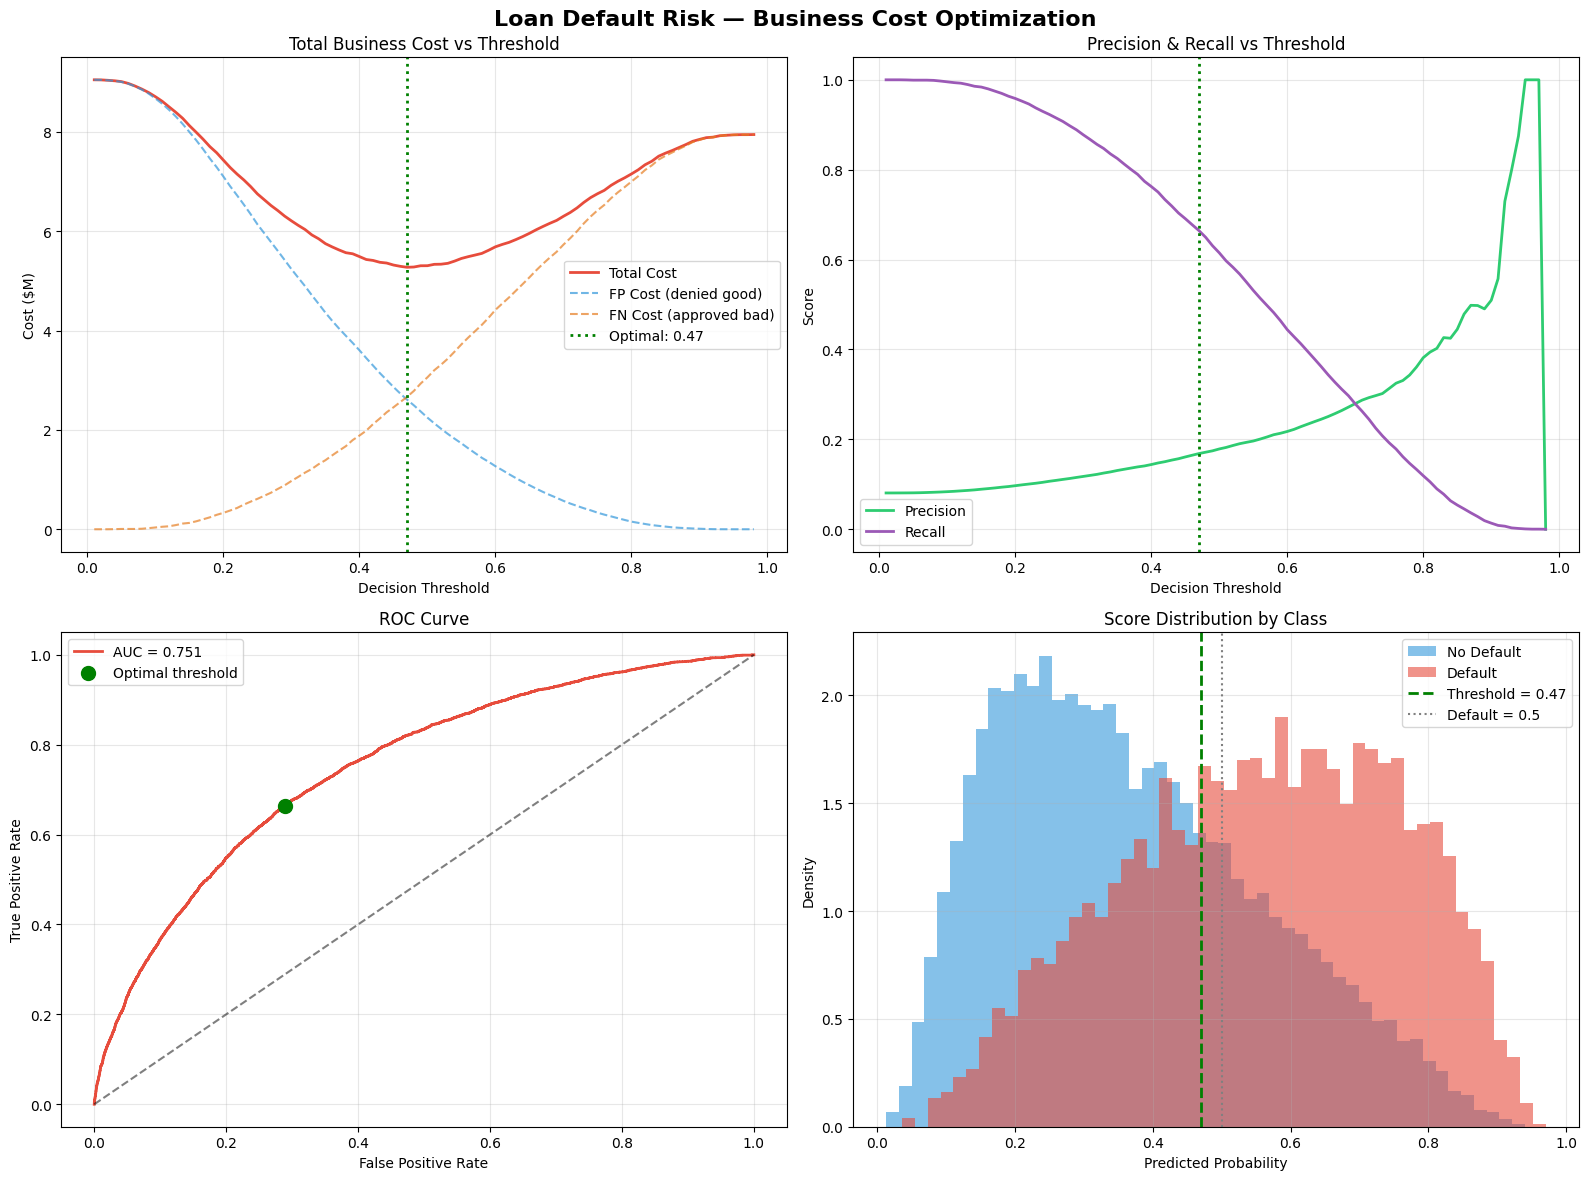

In [14]:
def plot_cost_analysis(cost_df, optimal, y_true, y_probs):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Loan Default Risk — Business Cost Optimization', 
                 fontsize=16, fontweight='bold')
    
    # ── Plot 1: Cost vs Threshold ────────────────────────────────────────
    ax1 = axes[0, 0]
    ax1.plot(cost_df['threshold'], cost_df['total_cost'] / 1e6, 
             color='#e74c3c', linewidth=2, label='Total Cost')
    ax1.plot(cost_df['threshold'], cost_df['fp_cost'] / 1e6, 
             '--', color='#3498db', alpha=0.7, label='FP Cost (denied good)')
    ax1.plot(cost_df['threshold'], cost_df['fn_cost'] / 1e6, 
             '--', color='#e67e22', alpha=0.7, label='FN Cost (approved bad)')
    ax1.axvline(optimal['threshold'], color='green', linestyle=':', 
                linewidth=2, label=f"Optimal: {optimal['threshold']:.2f}")
    ax1.set_xlabel('Decision Threshold')
    ax1.set_ylabel('Cost ($M)')
    ax1.set_title('Total Business Cost vs Threshold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # ── Plot 2: Precision-Recall Tradeoff ───────────────────────────────
    ax2 = axes[0, 1]
    ax2.plot(cost_df['threshold'], cost_df['precision'], 
             color='#2ecc71', linewidth=2, label='Precision')
    ax2.plot(cost_df['threshold'], cost_df['recall'], 
             color='#9b59b6', linewidth=2, label='Recall')
    ax2.axvline(optimal['threshold'], color='green', linestyle=':', linewidth=2)
    ax2.set_xlabel('Decision Threshold')
    ax2.set_ylabel('Score')
    ax2.set_title('Precision & Recall vs Threshold')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # ── Plot 3: ROC Curve ────────────────────────────────────────────────
    from sklearn.metrics import roc_curve, auc
    ax3 = axes[1, 0]
    fpr, tpr, roc_thresh = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    ax3.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {roc_auc:.3f}')
    ax3.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    
    # Mark optimal threshold on ROC
    opt_idx = np.argmin(np.abs(roc_thresh - optimal['threshold']))
    ax3.scatter(fpr[opt_idx], tpr[opt_idx], s=100, color='green', 
                zorder=5, label=f"Optimal threshold")
    ax3.set_xlabel('False Positive Rate')
    ax3.set_ylabel('True Positive Rate')
    ax3.set_title('ROC Curve')
    ax3.legend()
    ax3.grid(alpha=0.3)
    
    # ── Plot 4: Probability Distribution ────────────────────────────────
    ax4 = axes[1, 1]
    ax4.hist(y_probs[y_true == 0], bins=50, alpha=0.6, 
             color='#3498db', label='No Default', density=True)
    ax4.hist(y_probs[y_true == 1], bins=50, alpha=0.6, 
             color='#e74c3c', label='Default', density=True)
    ax4.axvline(optimal['threshold'], color='green', linestyle='--', 
                linewidth=2, label=f"Threshold = {optimal['threshold']:.2f}")
    ax4.axvline(0.5, color='gray', linestyle=':', 
                linewidth=1.5, label='Default = 0.5')
    ax4.set_xlabel('Predicted Probability')
    ax4.set_ylabel('Density')
    ax4.set_title('Score Distribution by Class')
    ax4.legend()
    ax4.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('cost_optimization.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_cost_analysis(cost_df, optimal, y_val, cb_probs_val)

#### Total Business Cost vs Threshold
The red curve (total cost) forms a U-shape — too low a threshold denies everyone (high FP cost), too high approves everyone (high FN cost). The green dotted line at 0.47 is the bottom of that U — the sweet spot where combined losses are minimized at $5.27M.<br>

#### Precision & Recall vs Threshold
The classic precision-recall tradeoff:<br>
As threshold rises → precision goes up (fewer false alarms) but recall drops (miss more defaulters)
At threshold 0.47: recall is ~0.66 (catches 66% of defaulters) but precision is only 0.17 (many false alarms) — acceptable because missing a defaulter costs 10× more than a false alarm.<br>

#### ROC Curve (AUC = 0.751)
The curve bows toward the top-left corner — a random model would follow the grey diagonal. The green dot marks your optimal threshold (0.47), sitting at roughly FPR=0.28, TPR=0.66, meaning the model catches 66% of defaulters while only wrongly flagging 28% of good customers.<br>

#### Score Distribution by Class
This is the most visually informative plot:<br>
Blue (No Default) peaks around 0.2 — most good customers get low risk scores <br>
Red (Default) spreads widely toward 1.0 — defaulters tend to get higher scores <br>
The two distributions heavily overlap in 0.3–0.6 range — this overlap is why AUC is 0.75 and not 0.90+
The green line (0.47) sits just before the overlap zone, slightly left of the default 0.5 (grey dotted) to catch slightly more defaulters given the cost asymmetry



#### Feature Importance

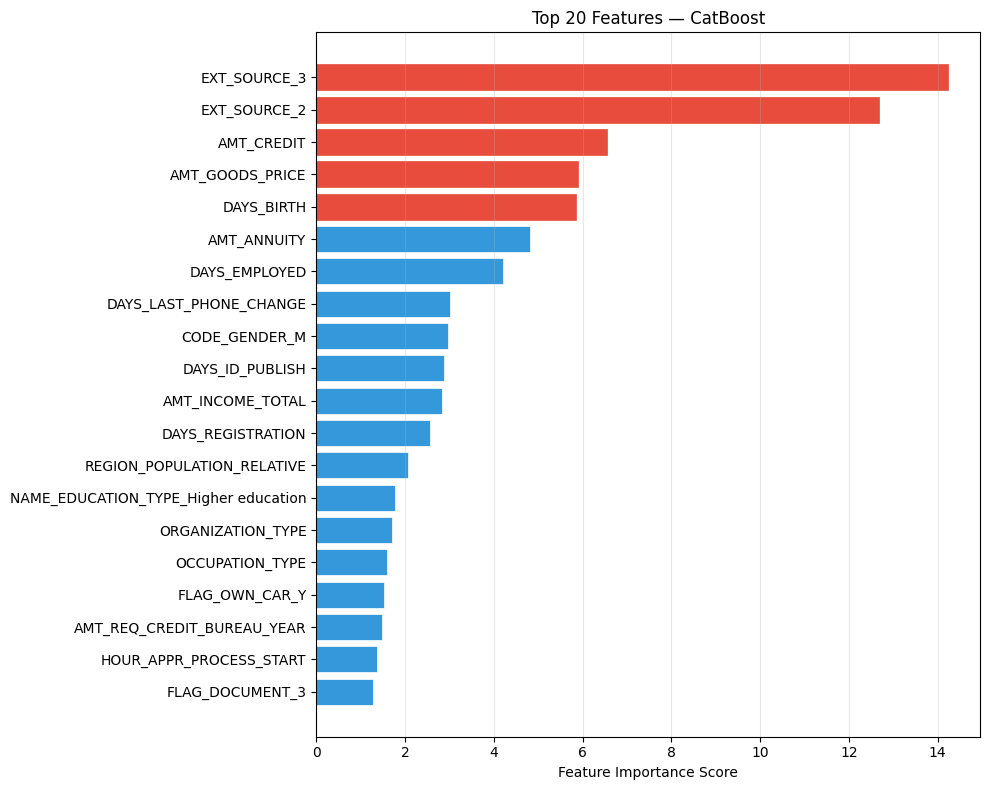


Top 10 Most Predictive Features:
               feature  importance
          EXT_SOURCE_3   14.243688
          EXT_SOURCE_2   12.678236
            AMT_CREDIT    6.547345
       AMT_GOODS_PRICE    5.893922
            DAYS_BIRTH    5.841824
           AMT_ANNUITY    4.824551
         DAYS_EMPLOYED    4.204222
DAYS_LAST_PHONE_CHANGE    3.016033
         CODE_GENDER_M    2.960397
       DAYS_ID_PUBLISH    2.886881


In [15]:
def plot_feature_importance(model, X, top_n=20):  #Plot top N feature importances from CatBoost.
    
   
    importances = model.get_feature_importance()
    feat_names = X.columns.tolist()
    
    importance_df = pd.DataFrame({
        'feature': feat_names,
        'importance': importances
    }).sort_values('importance', ascending=False).head(top_n)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(importance_df['feature'][::-1], 
                   importance_df['importance'][::-1],
                   color='#3498db', edgecolor='white', linewidth=0.5)
    
    # Color top 5 differently
    for i, bar in enumerate(bars[-5:]):
        bar.set_color('#e74c3c')
    
    ax.set_xlabel('Feature Importance Score')
    ax.set_title(f'Top {top_n} Features — CatBoost')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return importance_df


feat_importance = plot_feature_importance(catboost_model, X_train)
print("\nTop 10 Most Predictive Features:")
print(feat_importance.head(10).to_string(index=False))

These are the top 10 features CatBoost relied on most to predict loan default<br>
higher % = more decision-making power

#### Evaluation on Test Set

In [16]:
def final_evaluation(model, X_test, y_test, optimal_threshold, 
                      cost_fp=200, cost_fn=2000):
  
    from sklearn.metrics import (confusion_matrix, classification_report,
                                  roc_auc_score, average_precision_score)
    
    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs >= optimal_threshold).astype(int)
    
    print("="*60)
    print("FINAL TEST SET EVALUATION")
    print("="*60)
    print(f"\nAUC-ROC:  {roc_auc_score(y_test, probs):.4f}")
    print(f"Avg Precision (PR-AUC): {average_precision_score(y_test, probs):.4f}")
    
    print(f"\n--- At Optimal Threshold ({optimal_threshold:.2f}) ---")
    print(classification_report(y_test, preds, 
                                  target_names=['No Default', 'Default']))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, preds)
    print(f"Confusion Matrix:\n{cm}")
    
    # Business cost
    cost = compute_business_cost(y_test, probs, optimal_threshold, cost_fp, cost_fn)
    default_cost = compute_business_cost(y_test, probs, 0.5, cost_fp, cost_fn)
    
    print(f"\n--- Business Cost Summary ---")
    print(f"Cost at threshold {optimal_threshold:.2f}: ${cost['total_cost']:>12,.0f}")
    print(f"Cost at threshold 0.50:          ${default_cost['total_cost']:>12,.0f}")
    print(f"Savings from optimization:       ${default_cost['total_cost'] - cost['total_cost']:>12,.0f}")
    
    return probs, preds


test_probs, test_preds = final_evaluation(
    catboost_model, X_test, y_test, 
    optimal_threshold=optimal['threshold'],
    cost_fp=COST_FP, cost_fn=COST_FN
)

FINAL TEST SET EVALUATION

AUC-ROC:  0.7567
Avg Precision (PR-AUC): 0.2427

--- At Optimal Threshold (0.47) ---
              precision    recall  f1-score   support

  No Default       0.96      0.71      0.82     56538
     Default       0.17      0.66      0.27      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.69      0.54     61503
weighted avg       0.90      0.71      0.78     61503

Confusion Matrix:
[[40403 16135]
 [ 1668  3297]]

--- Business Cost Summary ---
Cost at threshold 0.47: $   6,563,000
Cost at threshold 0.50:          $   6,573,600
Savings from optimization:       $      10,600


Model correctly ranks a defaulter above a non-defaulter 75.67% of the time on completely unseen data — consistent with validation, no overfitting<br>
Only 24% precision on average across all thresholds — expected for imbalanced data where defaults are just 8% of loans<br>

                     Predicted No Default    Predicted Default
Actual No Default        40,403                 16,135 
Actual Default            1,668                 3,297 

Optimal threshold saves only $10,600 on test set — small because 0.47 and 0.50 are very close thresholds